***Predictive Retention Strategy for Credit Card Customers***

**EDA**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel('BankChurners.xlsx')

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [5]:
df.shape

(10127, 21)

In [6]:
df['Attrition_Flag'].unique()

array(['Existing Customer', 'Attrited Customer'], dtype=object)

In [7]:
df['Churn'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

In [8]:
df['Churn'].value_counts()

,count
Churn,
0,8500
1,1627


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [10]:
df_final = df.drop(columns=['CLIENTNUM', 'Customer_Age', 'Gender', 'Attrition_Flag'])

In [11]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Dependent_count           10127 non-null  int64  
 1   Education_Level           10127 non-null  object 
 2   Marital_Status            10127 non-null  object 
 3   Income_Category           10127 non-null  object 
 4   Card_Category             10127 non-null  object 
 5   Months_on_book            10127 non-null  int64  
 6   Total_Relationship_Count  10127 non-null  int64  
 7   Months_Inactive_12_mon    10127 non-null  int64  
 8   Contacts_Count_12_mon     10127 non-null  int64  
 9   Credit_Limit              10127 non-null  float64
 10  Total_Revolving_Bal       10127 non-null  int64  
 11  Avg_Open_To_Buy           10127 non-null  float64
 12  Total_Amt_Chng_Q4_Q1      10127 non-null  float64
 13  Total_Trans_Amt           10127 non-null  int64  
 14  Total_

In [12]:
df_final.shape

(10127, 18)

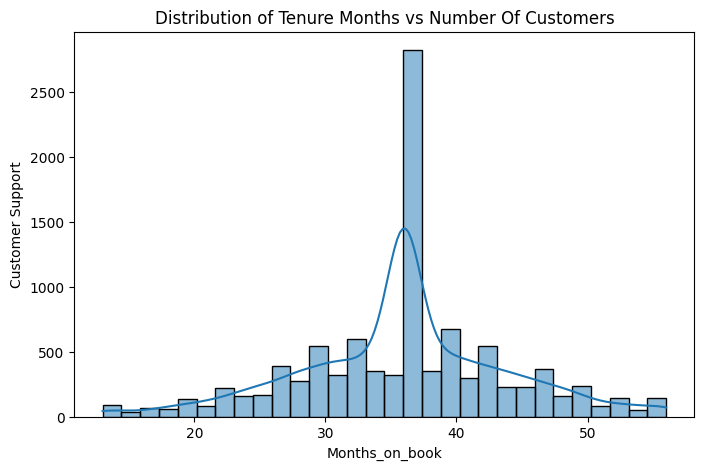

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df_final['Months_on_book'],bins=30,kde=True)
plt.xlabel('Months_on_book')
plt.ylabel('Customer Support')
plt.title('Distribution of Tenure Months vs Number Of Customers')
plt.show()

In [14]:
df_final['Months_on_book'].max()


56

In [15]:
df_final['Months_on_book'].min()

13

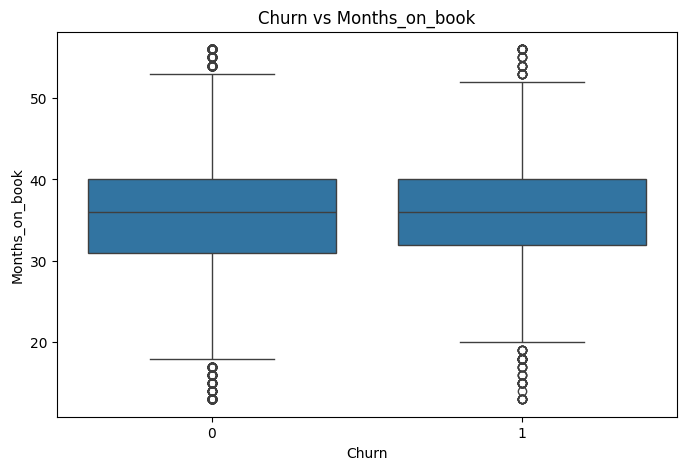

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Months_on_book',data=df_final)
plt.xlabel('Churn')
plt.ylabel('Months_on_book')
plt.title('Churn vs Months_on_book')
plt.show()

In [17]:
df_final['Total_Relationship_Count'].max()

6

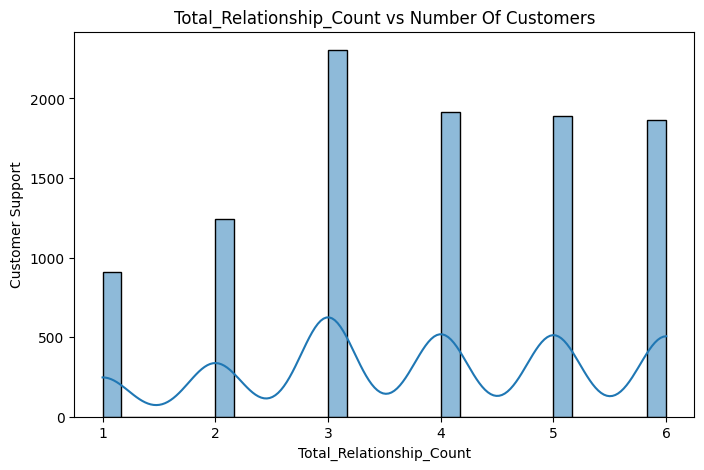

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total_Relationship_Count'],bins=30,kde=True)
plt.xlabel('Total_Relationship_Count')
plt.ylabel('Customer Support')
plt.title('Total_Relationship_Count vs Number Of Customers')
plt.show()

In [19]:
df['Total_Relationship_Count'].max()


6

In [20]:
df['Total_Relationship_Count'].min()

1

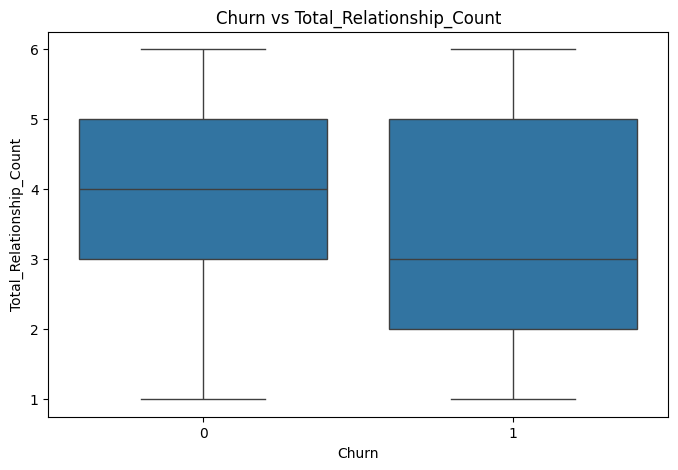

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Relationship_Count',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Relationship_Count')
plt.title('Churn vs Total_Relationship_Count')
plt.show()

In [22]:
df['Income_Category'].unique()

array(['$60K - $80K', 'Less than $40K', '$80K - $120K', '$40K - $60K',
       '$120K +', 'Unknown'], dtype=object)

In [23]:
df['Income_Category'].value_counts()

,count
Income_Category,
Less than $40K,3561
$40K - $60K,1790
$80K - $120K,1535
$60K - $80K,1402
Unknown,1112
$120K +,727


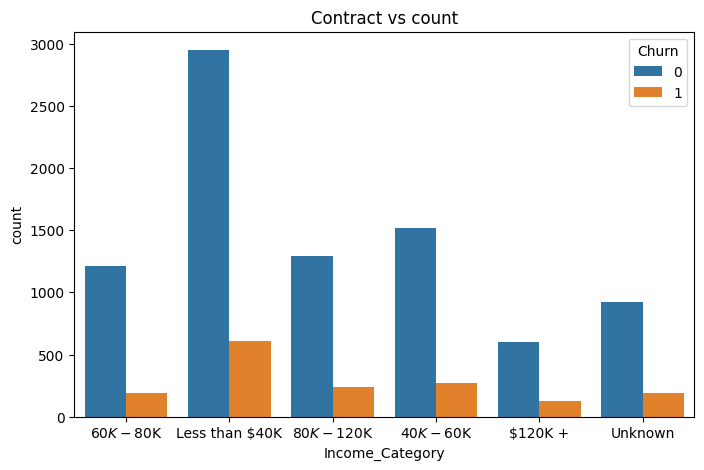

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(x='Income_Category',hue='Churn',data=df)
plt.xlabel('Income_Category')
plt.ylabel('count')
plt.title('Contract vs count')
plt.show()

In [25]:
df['Card_Category'].unique()

array(['Blue', 'Gold', 'Silver', 'Platinum'], dtype=object)

In [26]:
df['Card_Category'].value_counts()

,count
Card_Category,
Blue,9436
Silver,555
Gold,116
Platinum,20


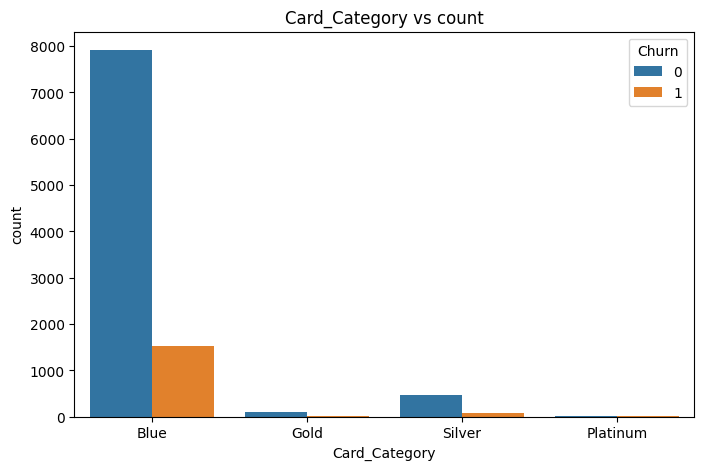

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='Card_Category',hue='Churn',data=df)
plt.xlabel('Card_Category')
plt.ylabel('count')
plt.title('Card_Category vs count')
plt.show()

In [28]:
df['Education_Level'].unique()

array(['High School', 'Graduate', 'Uneducated', 'Unknown', 'College',
       'Post-Graduate', 'Doctorate'], dtype=object)

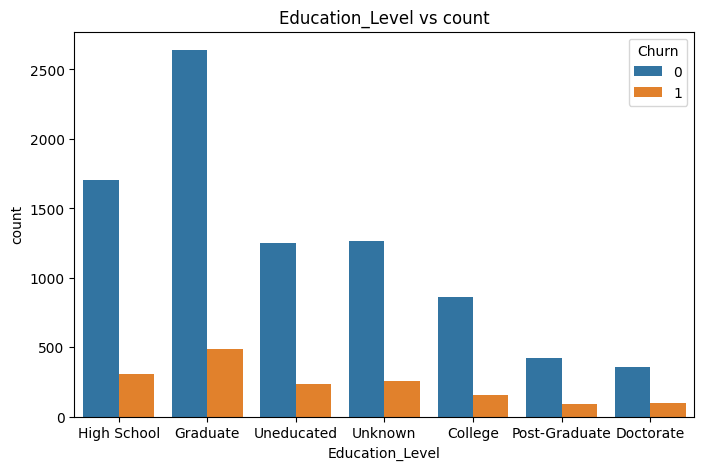

In [29]:
plt.figure(figsize=(8,5))
sns.countplot(x='Education_Level',hue='Churn',data=df)
plt.xlabel('Education_Level')
plt.ylabel('count')
plt.title('Education_Level vs count')
plt.show()

In [30]:
df['Marital_Status'].unique()

array(['Married', 'Single', 'Unknown', 'Divorced'], dtype=object)

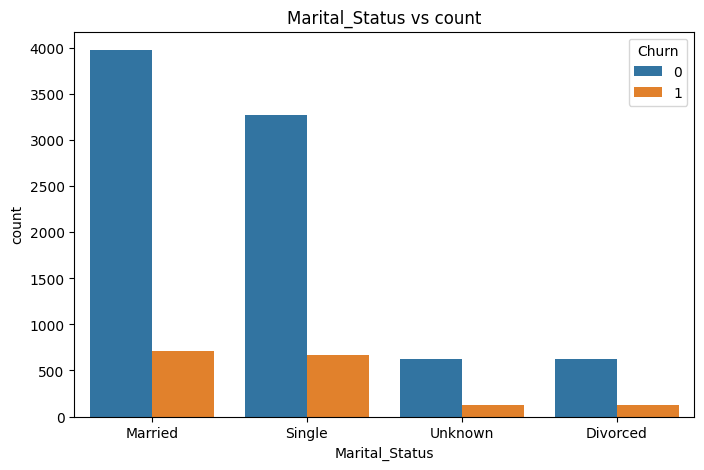

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Marital_Status',hue='Churn',data=df)
plt.xlabel('Marital_Status')
plt.ylabel('count')
plt.title('Marital_Status vs count')
plt.show()

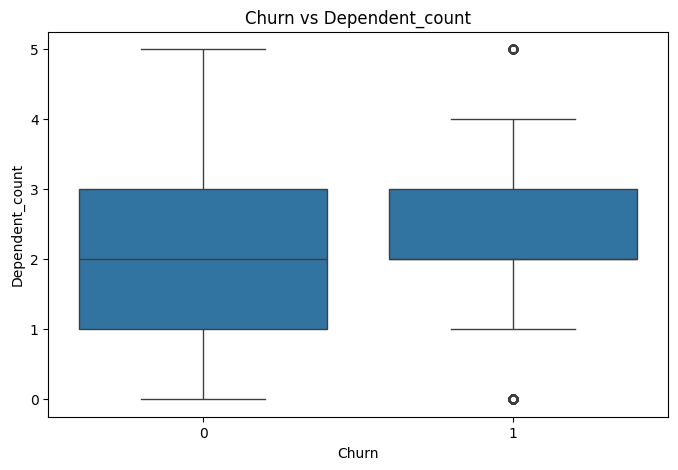

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Dependent_count',data=df)
plt.xlabel('Churn')
plt.ylabel('Dependent_count')
plt.title('Churn vs Dependent_count')
plt.show()

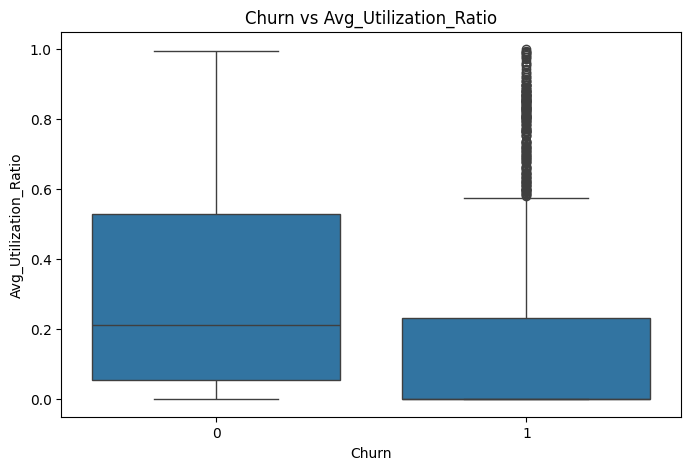

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Avg_Utilization_Ratio',data=df)
plt.xlabel('Churn')
plt.ylabel('Avg_Utilization_Ratio')
plt.title('Churn vs Avg_Utilization_Ratio')
plt.show()

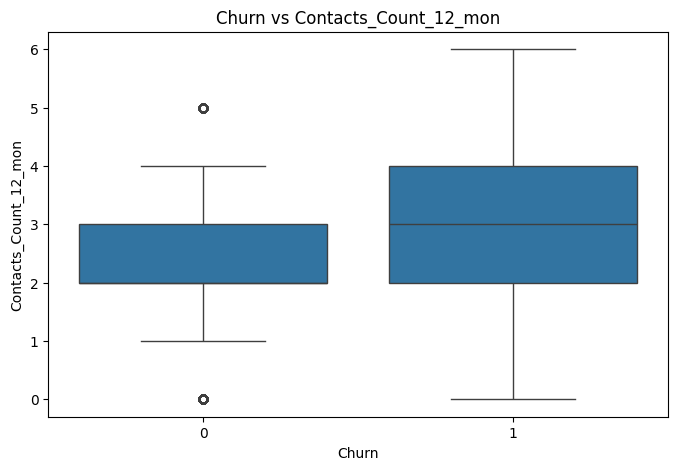

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Contacts_Count_12_mon',data=df)
plt.xlabel('Churn')
plt.ylabel('Contacts_Count_12_mon')
plt.title('Churn vs Contacts_Count_12_mon')
plt.show()

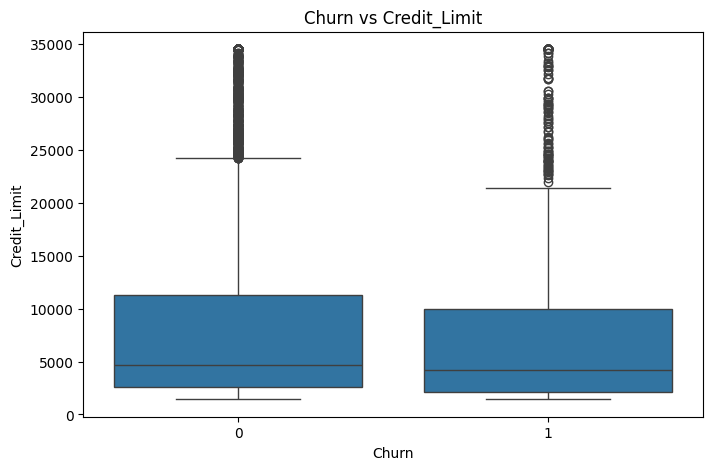

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Credit_Limit',data=df)
plt.xlabel('Churn')
plt.ylabel('Credit_Limit')
plt.title('Churn vs Credit_Limit')
plt.show()

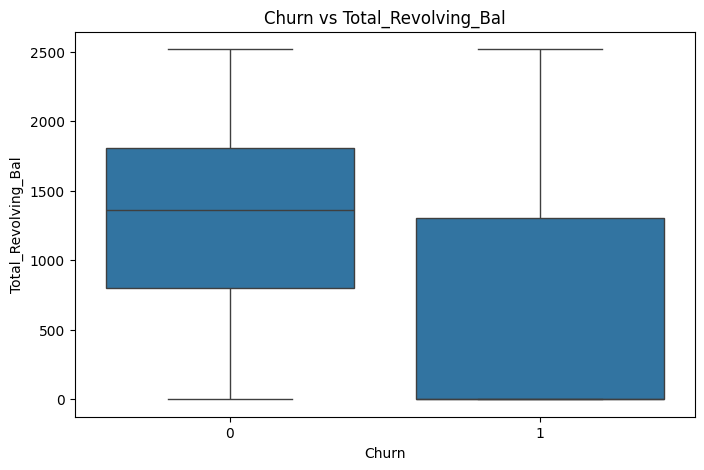

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Revolving_Bal',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Revolving_Bal')
plt.title('Churn vs Total_Revolving_Bal')
plt.show()

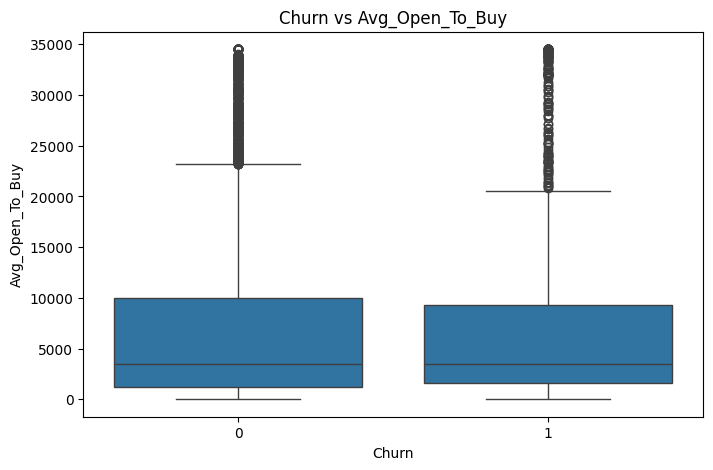

In [37]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Avg_Open_To_Buy',data=df)
plt.xlabel('Churn')
plt.ylabel('Avg_Open_To_Buy')
plt.title('Churn vs Avg_Open_To_Buy')
plt.show()

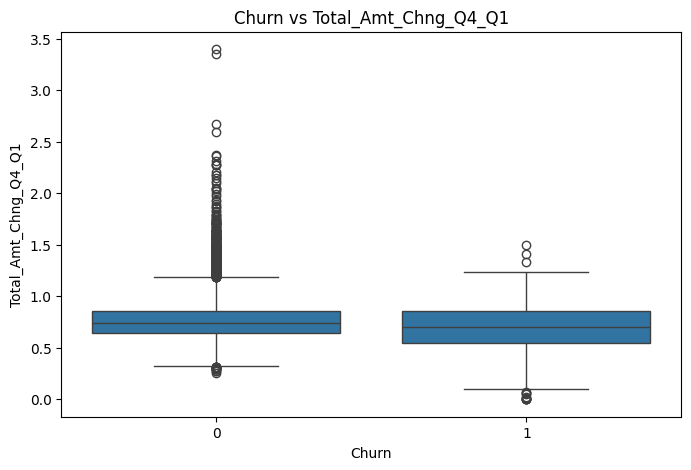

In [38]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Amt_Chng_Q4_Q1',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Amt_Chng_Q4_Q1')
plt.title('Churn vs Total_Amt_Chng_Q4_Q1')
plt.show()

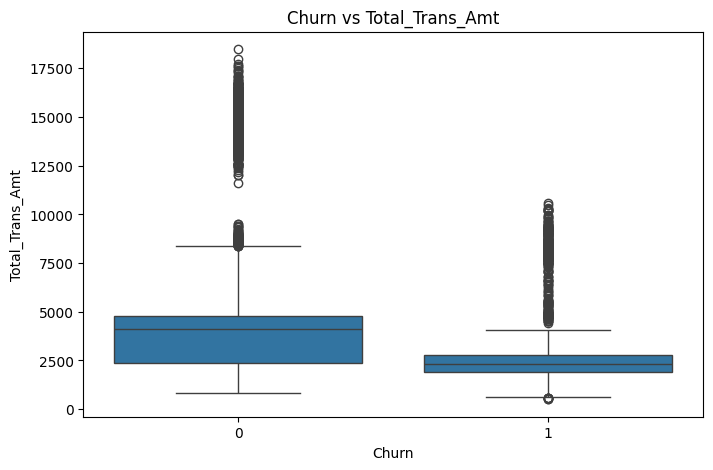

In [39]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Trans_Amt',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Trans_Amt')
plt.title('Churn vs Total_Trans_Amt')
plt.show()

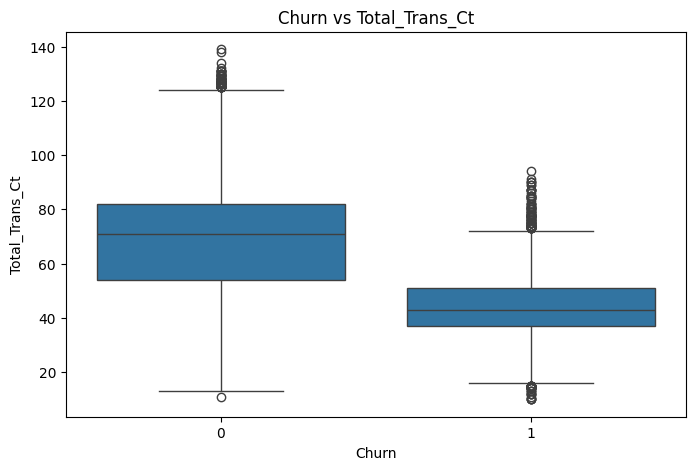

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Trans_Ct',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Trans_Ct')
plt.title('Churn vs Total_Trans_Ct')
plt.show()

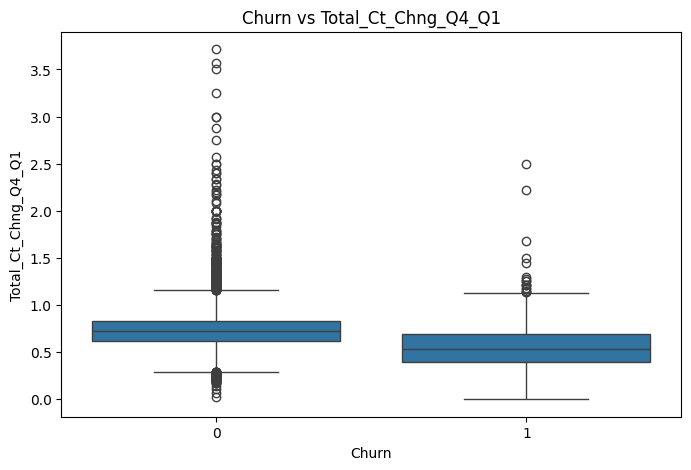

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn',y='Total_Ct_Chng_Q4_Q1',data=df)
plt.xlabel('Churn')
plt.ylabel('Total_Ct_Chng_Q4_Q1')
plt.title('Churn vs Total_Ct_Chng_Q4_Q1')
plt.show()

In [42]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Dependent_count           10127 non-null  int64  
 1   Education_Level           10127 non-null  object 
 2   Marital_Status            10127 non-null  object 
 3   Income_Category           10127 non-null  object 
 4   Card_Category             10127 non-null  object 
 5   Months_on_book            10127 non-null  int64  
 6   Total_Relationship_Count  10127 non-null  int64  
 7   Months_Inactive_12_mon    10127 non-null  int64  
 8   Contacts_Count_12_mon     10127 non-null  int64  
 9   Credit_Limit              10127 non-null  float64
 10  Total_Revolving_Bal       10127 non-null  int64  
 11  Avg_Open_To_Buy           10127 non-null  float64
 12  Total_Amt_Chng_Q4_Q1      10127 non-null  float64
 13  Total_Trans_Amt           10127 non-null  int64  
 14  Total_

In [43]:
numerical_cols=['Dependent_count','Months_on_book','Total_Relationship_Count','Months_Inactive_12_mon','Contacts_Count_12_mon','Credit_Limit','Total_Revolving_Bal','Avg_Open_To_Buy','Total_Amt_Chng_Q4_Q1','Total_Trans_Amt','Total_Trans_Ct','Total_Ct_Chng_Q4_Q1','Avg_Utilization_Ratio','Churn']
correlation_matrix=df_final[numerical_cols].corr()

In [44]:
correlation_matrix

,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Churn
Dependent_count,1.000000,-0.103062,-0.039076,-0.010768,-0.040505,0.068065,-0.002688,0.068291,-0.035439,0.025046,0.049912,0.011087,-0.037135,0.018991
Months_on_book,-0.103062,1.000000,-0.009203,0.074164,-0.010774,0.007507,0.008623,0.006732,-0.048959,-0.038591,-0.049819,-0.014072,-0.007541,0.013687
Total_Relationship_Count,-0.039076,-0.009203,1.000000,-0.003675,0.055203,-0.071386,0.013726,-0.072601,0.050119,-0.347229,-0.241891,0.040831,0.067663,-0.150005
Months_Inactive_12_mon,-0.010768,0.074164,-0.003675,1.000000,0.029493,-0.020394,-0.042210,-0.016605,-0.032247,-0.036982,-0.042787,-0.038989,-0.007503,0.152449
Contacts_Count_12_mon,-0.040505,-0.010774,0.055203,0.029493,1.000000,0.020817,-0.053913,0.025646,-0.024445,-0.112774,-0.152213,-0.094997,-0.055471,0.204491
Credit_Limit,0.068065,0.007507,-0.071386,-0.020394,0.020817,1.000000,0.042493,0.995981,0.012813,0.171730,0.075927,-0.002020,-0.482965,-0.023873
Total_Revolving_Bal,-0.002688,0.008623,0.013726,-0.042210,-0.053913,0.042493,1.000000,-0.047167,0.058174,0.064370,0.056060,0.089861,0.624022,-0.263053
Avg_Open_To_Buy,0.068291,0.006732,-0.072601,-0.016605,0.025646,0.995981,-0.047167,1.000000,0.007595,0.165923,0.070885,-0.010076,-0.538808,-0.000285
Total_Amt_Chng_Q4_Q1,-0.035439,-0.048959,0.050119,-0.032247,-0.024445,0.012813,0.058174,0.007595,1.000000,0.039678,0.005469,0.384189,0.035235,-0.131063
Total_Trans_Amt,0.025046,-0.038591,-0.347229,-0.036982,-0.112774,0.171730,0.064370,0.165923,0.039678,1.000000,0.807192,0.085581,-0.083034,-0.168598


In [45]:
ct1=pd.crosstab(df['Education_Level'], df_final['Churn'])

ct2=pd.crosstab(df['Income_Category'], df_final['Churn'])

ct3=pd.crosstab(df['Card_Category'], df_final['Churn'])

ct4=pd.crosstab(df['Marital_Status'], df_final['Churn'])

In [46]:
ct1,ct2,ct3,ct4

(Churn               0    1
 Education_Level           
 College           859  154
 Doctorate         356   95
 Graduate         2641  487
 High School      1707  306
 Post-Graduate     424   92
 Uneducated       1250  237
 Unknown          1263  256,
 Churn               0    1
 Income_Category           
 $120K +           601  126
 $40K - $60K      1519  271
 $60K - $80K      1213  189
 $80K - $120K     1293  242
 Less than $40K   2949  612
 Unknown           925  187,
 Churn             0     1
 Card_Category            
 Blue           7917  1519
 Gold             95    21
 Platinum         15     5
 Silver          473    82,
 Churn              0    1
 Marital_Status           
 Divorced         627  121
 Married         3978  709
 Single          3275  668
 Unknown          620  129)

***Data Cleaning***

In [47]:
print(df_final.isnull().sum())

Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
Churn                       0
dtype: int64


In [48]:
df_encoded=pd.get_dummies(df_final,drop_first=True)

In [49]:
df_encoded

,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,...,False,False,False,True,False,False,False,False,False,False
1,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,...,True,False,False,False,False,True,False,False,False,False
2,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,...,False,False,False,False,True,False,False,False,False,False
3,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,...,False,True,False,False,False,True,False,False,False,False
4,3,21,5,1,0,4716.0,0,4716.0,2.175,816,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,2,40,3,2,3,4003.0,1851,2152.0,0.703,15476,...,True,False,True,False,False,False,False,False,False,False
10123,2,25,4,2,3,4277.0,2186,2091.0,0.804,8764,...,False,False,True,False,False,False,False,False,False,False
10124,1,36,5,3,4,5409.0,0,5409.0,0.819,10291,...,False,False,False,False,False,True,False,False,False,False
10125,2,36,4,3,3,5281.0,0,5281.0,0.535,8395,...,False,True,True,False,False,False,False,False,False,False


In [50]:
df_encoded.shape

(10127, 31)

In [51]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dependent_count                 10127 non-null  int64  
 1   Months_on_book                  10127 non-null  int64  
 2   Total_Relationship_Count        10127 non-null  int64  
 3   Months_Inactive_12_mon          10127 non-null  int64  
 4   Contacts_Count_12_mon           10127 non-null  int64  
 5   Credit_Limit                    10127 non-null  float64
 6   Total_Revolving_Bal             10127 non-null  int64  
 7   Avg_Open_To_Buy                 10127 non-null  float64
 8   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 9   Total_Trans_Amt                 10127 non-null  int64  
 10  Total_Trans_Ct                  10127 non-null  int64  
 11  Total_Ct_Chng_Q4_Q1             10127 non-null  float64
 12  Avg_Utilization_Ratio           

In [52]:
df_encoded.head(10)

,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,...,Marital_Status_Single,Marital_Status_Unknown,Income_Category_$40K - $60K,Income_Category_$60K - $80K,Income_Category_$80K - $120K,Income_Category_Less than $40K,Income_Category_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,3,39,5,1,3,12691.0,777,11914.0,1.335,1144,...,False,False,False,True,False,False,False,False,False,False
1,5,44,6,1,2,8256.0,864,7392.0,1.541,1291,...,True,False,False,False,False,True,False,False,False,False
2,3,36,4,1,0,3418.0,0,3418.0,2.594,1887,...,False,False,False,False,True,False,False,False,False,False
3,4,34,3,4,1,3313.0,2517,796.0,1.405,1171,...,False,True,False,False,False,True,False,False,False,False
4,3,21,5,1,0,4716.0,0,4716.0,2.175,816,...,False,False,False,True,False,False,False,False,False,False
5,2,36,3,1,2,4010.0,1247,2763.0,1.376,1088,...,False,False,True,False,False,False,False,False,False,False
6,4,46,6,1,3,34516.0,2264,32252.0,1.975,1330,...,False,False,False,False,False,False,False,True,False,False
7,0,27,2,2,2,29081.0,1396,27685.0,2.204,1538,...,False,True,False,True,False,False,False,False,False,True
8,3,36,5,2,0,22352.0,2517,19835.0,3.355,1350,...,True,False,False,True,False,False,False,False,False,False
9,2,36,6,3,3,11656.0,1677,9979.0,1.524,1441,...,True,False,False,False,True,False,False,False,False,False


In [53]:
x=df_encoded.drop('Churn',axis=1)
y=df_encoded['Churn']

In [54]:
x.shape

(10127, 30)

In [55]:
y.shape

(10127,)

In [56]:
print(x)


       Dependent_count  Months_on_book  Total_Relationship_Count  \
0                    3              39                         5   
1                    5              44                         6   
2                    3              36                         4   
3                    4              34                         3   
4                    3              21                         5   
...                ...             ...                       ...   
10122                2              40                         3   
10123                2              25                         4   
10124                1              36                         5   
10125                2              36                         4   
10126                2              25                         6   

       Months_Inactive_12_mon  Contacts_Count_12_mon  Credit_Limit  \
0                           1                      3       12691.0   
1                           1              

In [57]:
print(y)

0        0
1        0
2        0
3        0
4        0
        ..
10122    0
10123    1
10124    1
10125    1
10126    1
Name: Churn, Length: 10127, dtype: int64


***Machine Learning***

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [60]:
x_train.shape

(8101, 30)

In [61]:
x_test.shape

(2026, 30)

In [62]:
y_train.shape

(8101,)

In [63]:
y_test.shape

(2026,)

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [66]:
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [67]:
y_pred=rf_model.predict(x_test)

In [68]:
y_test

,Churn
3781,0
2922,0
5070,0
7246,0
623,0
...,...
1937,0
4705,1
8548,0
1346,0


In [69]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [70]:
from sklearn.metrics import accuracy_score

In [71]:
accuracy=accuracy_score(y_test,y_pred)

In [72]:
accuracy

0.9531095755182626

In [73]:
from sklearn.metrics import confusion_matrix

In [74]:
cm=confusion_matrix(y_test,y_pred)

In [75]:
print(cm)

[[1677   22]
 [  73  254]]


In [76]:
from sklearn.metrics import classification_report

In [77]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1699
           1       0.92      0.78      0.84       327

    accuracy                           0.95      2026
   macro avg       0.94      0.88      0.91      2026
weighted avg       0.95      0.95      0.95      2026



***Approach 1-Handle Class Imbalance***

In [78]:
rf_balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)


In [79]:
print(accuracy_balanced)


0.9491609081934848


In [80]:
print(cm_balanced)

[[1678   21]
 [  82  245]]


In [81]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1699
           1       0.92      0.75      0.83       327

    accuracy                           0.95      2026
   macro avg       0.94      0.87      0.90      2026
weighted avg       0.95      0.95      0.95      2026



**Approach 2- Hyperparameter Tuning**

In [82]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_tuned.fit(x_train,y_train)
y_pred_tuned=rf_tuned.predict(x_test)

print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1699
           1       0.84      0.85      0.85       327

    accuracy                           0.95      2026
   macro avg       0.91      0.91      0.91      2026
weighted avg       0.95      0.95      0.95      2026



***Approach-3 Feature Importance Analysis***




In [83]:
import pandas as pd
feature_importance=pd.DataFrame({'features':x.columns,'importance':rf_tuned.feature_importances_})
feature_importance_=feature_importance.sort_values(by='importance',ascending=False)
print(feature_importance_)

                          features  importance
9                  Total_Trans_Amt    0.219328
10                  Total_Trans_Ct    0.215018
6              Total_Revolving_Bal    0.117481
11             Total_Ct_Chng_Q4_Q1    0.097150
12           Avg_Utilization_Ratio    0.066214
8             Total_Amt_Chng_Q4_Q1    0.062000
2         Total_Relationship_Count    0.044495
3           Months_Inactive_12_mon    0.033523
7                  Avg_Open_To_Buy    0.029462
4            Contacts_Count_12_mon    0.028503
5                     Credit_Limit    0.027714
1                   Months_on_book    0.021921
0                  Dependent_count    0.008127
19          Marital_Status_Married    0.003437
25  Income_Category_Less than $40K    0.002704
20           Marital_Status_Single    0.002508
24    Income_Category_$80K - $120K    0.002352
23     Income_Category_$60K - $80K    0.002193
14        Education_Level_Graduate    0.001872
22     Income_Category_$40K - $60K    0.001743
15     Educat

/tmp/ipykernel_4340/1228277261.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='features', data=top_features, palette='viridis')


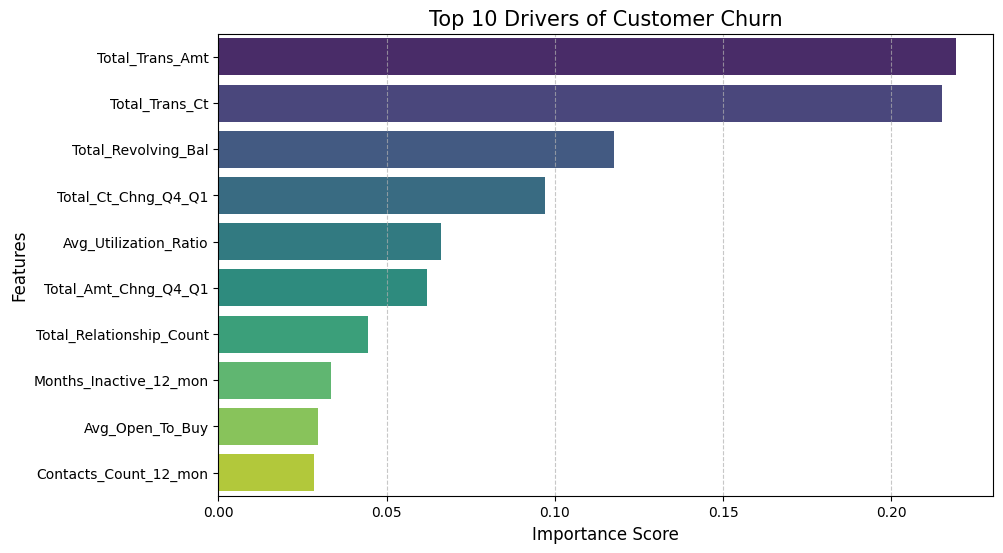

In [84]:
plt.figure(figsize=(10, 6))
top_features = feature_importance_.head(10)
sns.barplot(x='importance', y='features', data=top_features, palette='viridis')
plt.title('Top 10 Drivers of Customer Churn', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [85]:
print(feature_importance_.tail(15))

                         features  importance
20          Marital_Status_Single    0.002508
24   Income_Category_$80K - $120K    0.002352
23    Income_Category_$60K - $80K    0.002193
14       Education_Level_Graduate    0.001872
22    Income_Category_$40K - $60K    0.001743
15    Education_Level_High School    0.001709
18        Education_Level_Unknown    0.001643
26        Income_Category_Unknown    0.001475
17     Education_Level_Uneducated    0.001427
16  Education_Level_Post-Graduate    0.001313
13      Education_Level_Doctorate    0.001295
21         Marital_Status_Unknown    0.001140
29           Card_Category_Silver    0.001119
27             Card_Category_Gold    0.000847
28         Card_Category_Platinum    0.000286


In [86]:
x_selected=x.drop(['Card_Category_Platinum','Card_Category_Gold','Card_Category_Silver','Marital_Status_Unknown','Education_Level_Doctorate','Education_Level_Post-Graduate','Education_Level_Uneducated','Income_Category_Unknown','Education_Level_Unknown','Education_Level_High School','Income_Category_$40K - $60K','Education_Level_Graduate','Income_Category_$60K - $80K','Income_Category_$80K - $120K','Marital_Status_Single'],axis=1)

In [87]:
x_train_sel,x_test_sel,y_train_sel,y_test_sel=train_test_split(x_selected,y,test_size=0.2,random_state=42)

In [88]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(x_train_sel,y_train_sel)
y_pred_selected=rf_selected.predict(x_test_sel)

print(classification_report(y_test_sel,y_pred_selected))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1699
           1       0.86      0.87      0.87       327

    accuracy                           0.96      2026
   macro avg       0.92      0.92      0.92      2026
weighted avg       0.96      0.96      0.96      2026



Approach:- with combination of trees/n_estimators and depth

In [89]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [90]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20]
results=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_trees,max_depth=depth,random_state=42,class_weight='balanced')
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1 Score':f1})
result_df=pd.DataFrame(results)
result_df=result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy    Recall  Precision  F1 Score
0     100      5  0.894373  0.880734   0.622030  0.729114
12    400      5  0.893386  0.871560   0.620915  0.725191
8     300      5  0.892399  0.871560   0.618221  0.723350
16    500      5  0.892399  0.871560   0.618221  0.723350
4     200      5  0.889931  0.871560   0.611588  0.718789
5     200     10  0.951135  0.862385   0.839286  0.850679
9     300     10  0.950642  0.850153   0.844985  0.847561
1     100     10  0.950148  0.850153   0.842424  0.846271
13    400     10  0.950148  0.850153   0.842424  0.846271
17    500     10  0.949654  0.850153   0.839879  0.844985
14    400     15  0.953110  0.792049   0.905594  0.845024
6     200     15  0.951629  0.782875   0.904594  0.839344
10    300     15  0.950642  0.779817   0.901060  0.836066
18    500     15  0.951135  0.776758   0.907143  0.836903
15    400     20  0.951629  0.767584   0.919414  0.836667
19    500     20  0.951629  0.767584   0.919414  0.836667
11    300     

In [91]:
from sklearn.model_selection import cross_val_score

final_rf=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')

cv_accuracy=cross_val_score(final_rf,x,y,cv=5,scoring='accuracy')

In [92]:
cv_accuracy


array([0.84452122, 0.92152024, 0.97333333, 0.97925926, 0.84148148])

In [93]:
from sklearn.model_selection import cross_val_score

final_rfa=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')

cv_recall=cross_val_score(final_rfa,x,y,cv=5,scoring='recall')

In [94]:
cv_recall

array([0.73312883, 0.94785276, 0.86153846, 0.87692308, 0.02153846])

In [95]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 1: Sirf Stratified check karo (Accuracy)
cv_acc_strat = cross_val_score(final_rf, x, y, cv=skf, scoring='accuracy')
print("Accuracy Scores (Stratified):", cv_acc_strat)
print("Mean:", cv_acc_strat.mean())

Accuracy Scores (Stratified): [0.94471866 0.95014808 0.94469136 0.95259259 0.95259259]
Mean: 0.948948655137533


In [96]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 2:  Stratified check karo (Recall)
cv_acc_rs = cross_val_score(final_rf, x, y, cv=skf, scoring='recall')
print("Recall Scores (Stratified):", cv_acc_rs)
print("Mean:", cv_acc_rs.mean())

Recall Scores (Stratified): [0.85582822 0.87730061 0.83384615 0.88       0.83692308]
Mean: 0.8567796130250118


***OPTIONAL***

In [97]:
from sklearn.metrics import roc_curve,roc_auc_score

In [98]:
import matplotlib.pyplot as plt

In [99]:
y_prob=rf_tuned.predict_proba(x_test)

In [100]:
y_prob1=rf_tuned.predict_proba(x_test)



In [101]:
churn_prob=y_prob[:,1]



In [102]:
fpr,tpr,threshold=roc_curve(y_test,churn_prob)



In [103]:
auc_score=roc_auc_score(y_test,churn_prob)



In [104]:
print(auc_score)

0.9834513196285637


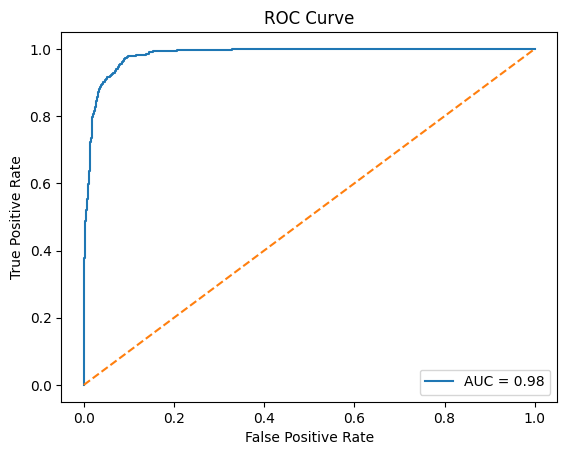

In [105]:
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--') # Diagonal line (Random Guess)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [106]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Dependent_count                 10127 non-null  int64  
 1   Months_on_book                  10127 non-null  int64  
 2   Total_Relationship_Count        10127 non-null  int64  
 3   Months_Inactive_12_mon          10127 non-null  int64  
 4   Contacts_Count_12_mon           10127 non-null  int64  
 5   Credit_Limit                    10127 non-null  float64
 6   Total_Revolving_Bal             10127 non-null  int64  
 7   Avg_Open_To_Buy                 10127 non-null  float64
 8   Total_Amt_Chng_Q4_Q1            10127 non-null  float64
 9   Total_Trans_Amt                 10127 non-null  int64  
 10  Total_Trans_Ct                  10127 non-null  int64  
 11  Total_Ct_Chng_Q4_Q1             10127 non-null  float64
 12  Avg_Utilization_Ratio           

***Customer Segregation***

In [107]:
segmentation_data = pd.DataFrame({
    'Tenure': x_test['Months_on_book'],
    'TotalRevBalance': x_test['Total_Revolving_Bal'],
    'TotalTransCount': x_test['Total_Trans_Ct'],
    'AvgUtilization': x_test['Avg_Utilization_Ratio'],
    'Contact': x_test['Contacts_Count_12_mon'],
    'ChurnProbability':churn_prob
})

In [108]:
segmentation_data

,Tenure,TotalRevBalance,TotalTransCount,AvgUtilization,Contact,ChurnProbability
3781,39,1508,64,0.504,4,0.036678
2922,53,1569,79,0.716,4,0.017443
5070,36,987,67,0.569,3,0.011917
7246,36,1516,74,0.317,3,0.062902
623,33,2170,35,0.584,2,0.412584
...,...,...,...,...,...,...
1937,29,1678,69,0.125,3,0.051504
4705,25,1791,42,0.803,4,0.771470
8548,37,1235,75,0.221,3,0.044001
1346,17,1354,36,0.155,2,0.320581


***Implemetation of kmeans***

In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [110]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[ 0.38968161  0.41270432 -0.02863341  0.79406346  1.35181905 -0.65143249]
 [ 2.17702461  0.48774941  0.61977891  1.55139852  1.35181905 -0.72219724]
 [ 0.00667954 -0.22825463  0.10104905  1.02626525  0.4651938  -0.74252983]
 [ 0.00667954  0.4225463   0.40364147  0.12603678  0.4651938  -0.55495109]
 [-0.37632254  1.22712816 -1.28223056  1.07985028 -0.42143145  0.73155303]]


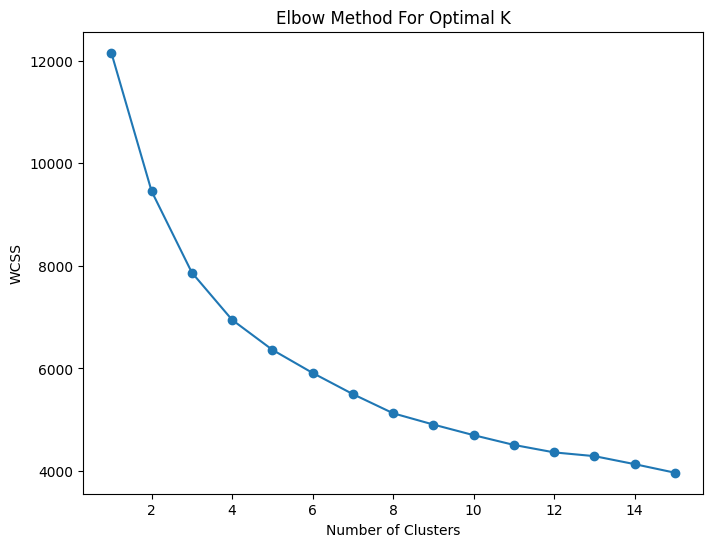

In [111]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42,n_init='auto')
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method For Optimal K')
plt.show()

In [112]:
kmeans=KMeans(n_clusters=4,random_state=42,n_init='auto')

In [113]:
clusters=kmeans.fit_predict(scaled_data)

In [114]:
segmentation_data

,Tenure,TotalRevBalance,TotalTransCount,AvgUtilization,Contact,ChurnProbability
3781,39,1508,64,0.504,4,0.036678
2922,53,1569,79,0.716,4,0.017443
5070,36,987,67,0.569,3,0.011917
7246,36,1516,74,0.317,3,0.062902
623,33,2170,35,0.584,2,0.412584
...,...,...,...,...,...,...
1937,29,1678,69,0.125,3,0.051504
4705,25,1791,42,0.803,4,0.771470
8548,37,1235,75,0.221,3,0.044001
1346,17,1354,36,0.155,2,0.320581


In [115]:
segmentation_data['Revenue_At_Risk'] = segmentation_data['ChurnProbability'] * segmentation_data['TotalRevBalance']

In [116]:
segmentation_data['Cluster']=clusters

In [117]:
segmentation_data

,Tenure,TotalRevBalance,TotalTransCount,AvgUtilization,Contact,ChurnProbability,Revenue_At_Risk,Cluster
3781,39,1508,64,0.504,4,0.036678,55.309926,1
2922,53,1569,79,0.716,4,0.017443,27.368466,1
5070,36,987,67,0.569,3,0.011917,11.761780,1
7246,36,1516,74,0.317,3,0.062902,95.359538,1
623,33,2170,35,0.584,2,0.412584,895.307237,2
...,...,...,...,...,...,...,...,...
1937,29,1678,69,0.125,3,0.051504,86.423449,0
4705,25,1791,42,0.803,4,0.771470,1381.702612,2
8548,37,1235,75,0.221,3,0.044001,54.341697,0
1346,17,1354,36,0.155,2,0.320581,434.067195,2


In [118]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [119]:
cluster_summary

,Tenure,TotalRevBalance,TotalTransCount,AvgUtilization,Contact,ChurnProbability,Revenue_At_Risk
Cluster,,,,,,,
0,36.529688,686.290625,79.951562,0.075294,2.267187,0.079059,37.155746
1,34.676678,1723.971731,78.789753,0.538362,2.270318,0.035698,67.996061
2,37.149533,1719.031776,41.590654,0.393475,2.646729,0.283534,507.414966
3,34.908772,143.442105,45.582456,0.025796,3.028070,0.738766,94.073254


In [120]:
cluster_names = {
    0: 'Loyal Premium Users',      # High Transactions, Very Low Churn
    1: 'Stable High-Balance Users', # High Balance, Very Low Churn
    2: 'Cooling-Off Customers',     # Dropping Transactions, Medium Churn Risk
    3: 'High-Risk/Frustrated'       # High Contact, Very High Churn Probability
}

In [121]:
segmentation_data['Customer_Segment'] = segmentation_data['Cluster'].map(cluster_names)

In [122]:
segmentation_data

,Tenure,TotalRevBalance,TotalTransCount,AvgUtilization,Contact,ChurnProbability,Revenue_At_Risk,Cluster,Customer_Segment
3781,39,1508,64,0.504,4,0.036678,55.309926,1,Stable High-Balance Users
2922,53,1569,79,0.716,4,0.017443,27.368466,1,Stable High-Balance Users
5070,36,987,67,0.569,3,0.011917,11.761780,1,Stable High-Balance Users
7246,36,1516,74,0.317,3,0.062902,95.359538,1,Stable High-Balance Users
623,33,2170,35,0.584,2,0.412584,895.307237,2,Cooling-Off Customers
...,...,...,...,...,...,...,...,...,...
1937,29,1678,69,0.125,3,0.051504,86.423449,0,Loyal Premium Users
4705,25,1791,42,0.803,4,0.771470,1381.702612,2,Cooling-Off Customers
8548,37,1235,75,0.221,3,0.044001,54.341697,0,Loyal Premium Users
1346,17,1354,36,0.155,2,0.320581,434.067195,2,Cooling-Off Customers


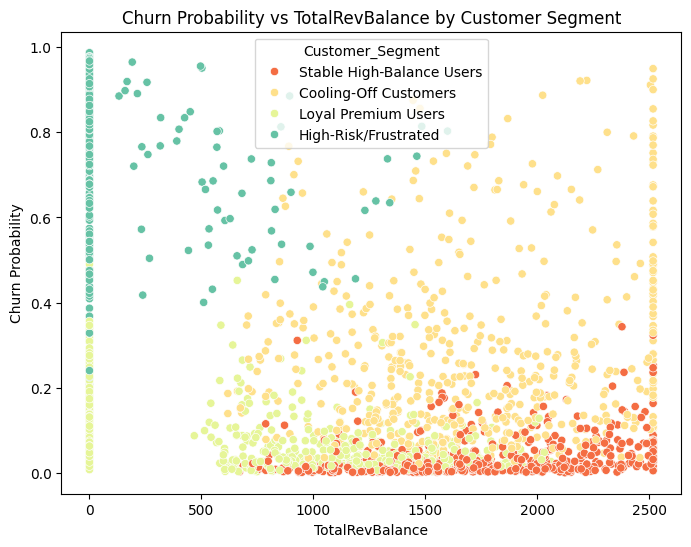

In [123]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TotalRevBalance', y='ChurnProbability', hue='Customer_Segment', data=segmentation_data, palette='Spectral')
plt.xlabel('TotalRevBalance')
plt.ylabel('Churn Probability')
plt.title('Churn Probability vs TotalRevBalance by Customer Segment')
plt.show()

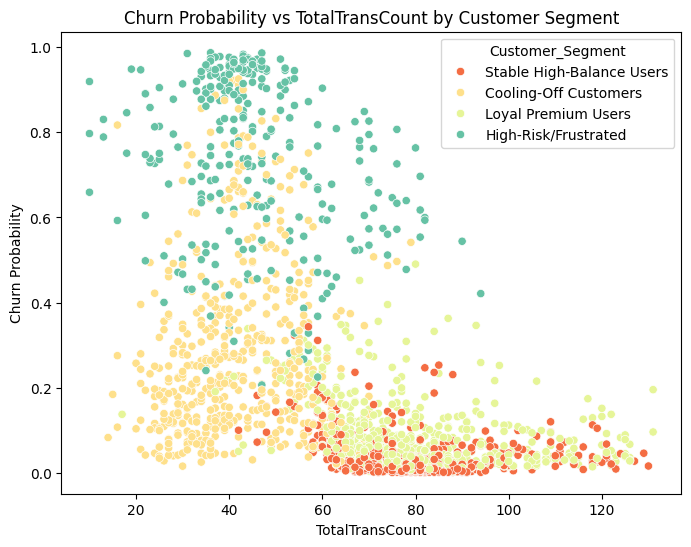

In [124]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='TotalTransCount', y='ChurnProbability', hue='Customer_Segment', data=segmentation_data, palette='Spectral')
plt.xlabel('TotalTransCount')
plt.ylabel('Churn Probability')
plt.title('Churn Probability vs TotalTransCount by Customer Segment')
plt.show()

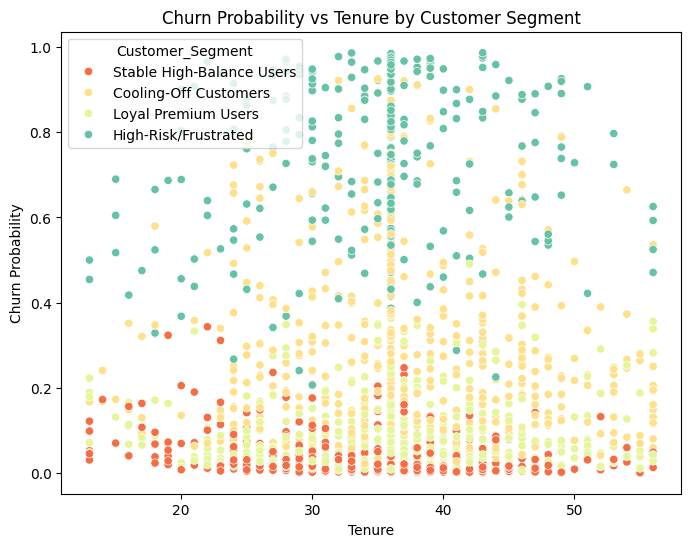

In [125]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure', y='ChurnProbability', hue='Customer_Segment', data=segmentation_data, palette='Spectral')
plt.xlabel('Tenure')
plt.ylabel('Churn Probability')
plt.title('Churn Probability vs Tenure by Customer Segment')
plt.show()

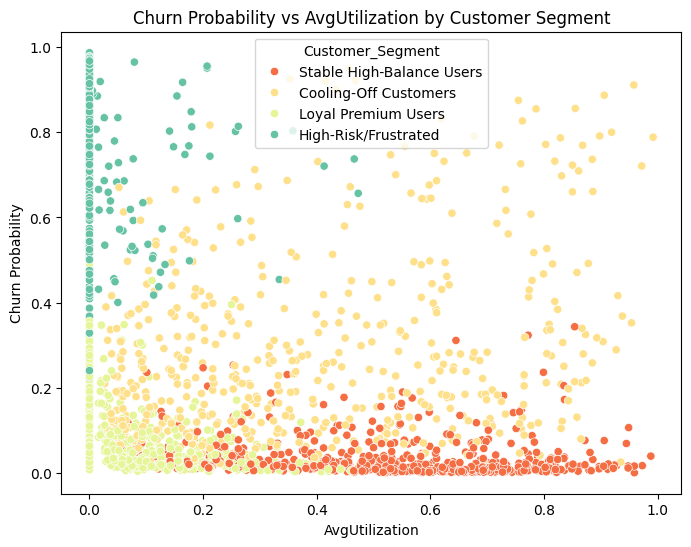

In [126]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='AvgUtilization', y='ChurnProbability', hue='Customer_Segment', data=segmentation_data, palette='Spectral')
plt.xlabel('AvgUtilization')
plt.ylabel('Churn Probability')
plt.title('Churn Probability vs AvgUtilization by Customer Segment')
plt.show()

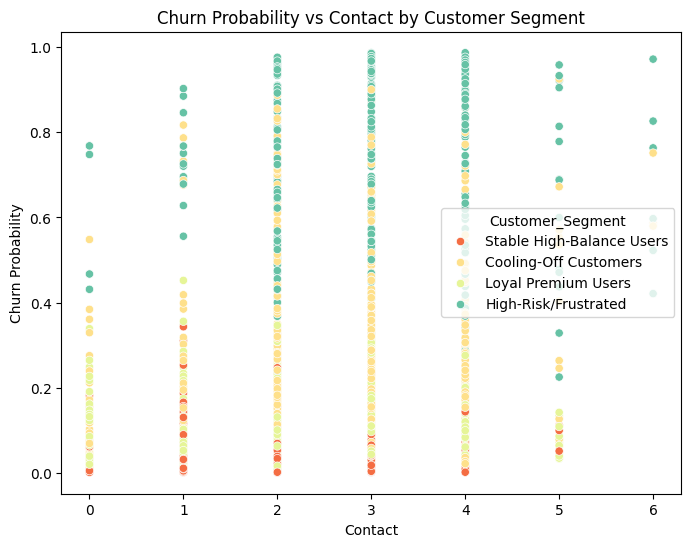

In [127]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Contact', y='ChurnProbability', hue='Customer_Segment', data=segmentation_data, palette='Spectral')
plt.xlabel('Contact')
plt.ylabel('Churn Probability')
plt.title('Churn Probability vs Contact by Customer Segment')
plt.show()

In [128]:
# Retention Strategy Map (4-Segment Model)
print("--- Recommended Retention Strategies by Segment ---")

strategy_map = {
    'Loyal Premium': 'Offer exclusive loyalty rewards and VIP service tiers to maintain high ARPU and brand advocacy.',
    'Stable High-Balance': 'Provide personalized financial planning tools or high-yield investment options to keep capital engaged.',
    'Cooling-Off': 'Deploy targeted win-back campaigns, such as limited-time discounts or free service trials, to re-ignite activity.',
    'High-Risk': 'Immediate Intervention: Trigger high-priority "Save Team" outreach, service audits, and loyalty credits to prevent churn.'
}

for segment, strategy in strategy_map.items():
    print(f"\n[Segment: {segment}]")
    print(f"Strategic Action: {strategy}")

--- Recommended Retention Strategies by Segment ---

[Segment: Loyal Premium]
Strategic Action: Offer exclusive loyalty rewards and VIP service tiers to maintain high ARPU and brand advocacy.

[Segment: Stable High-Balance]
Strategic Action: Provide personalized financial planning tools or high-yield investment options to keep capital engaged.

[Segment: Cooling-Off]
Strategic Action: Deploy targeted win-back campaigns, such as limited-time discounts or free service trials, to re-ignite activity.

[Segment: High-Risk]
Strategic Action: Immediate Intervention: Trigger high-priority "Save Team" outreach, service audits, and loyalty credits to prevent churn.
